**Навигация по уроку**

1. [Анализ временных рядов с помощью НС](https://colab.research.google.com/drive/1q9nM-aWF6wZ2XuBxjQEAgjKxrL45axit)
2. [Сравнение архитектур нейронных сетей для обработки временных рядов](https://colab.research.google.com/drive/1-D-qXFYJ9b5sLLz_CFkUYmR-I2tM7KO2)
3. Домашняя работа

**В домашней работе вам необходимо:**
1. Выбрать любую понравившуюся модель из [практической](https://colab.research.google.com/drive/1-D-qXFYJ9b5sLLz_CFkUYmR-I2tM7KO2) части урока.
2. Используя известный [датасет](https://storage.yandexcloud.net/academy.ai/AAPL.csv) котировок Apple, обучить модель. Вывести графики из урока: график процесса обучения, сопоставления базового и прогнозного рядов, а также график автокорреляции.
3. Для получения трех проходных баллов за урок необходимо скорректировать код урока для данных с batch_size не равному 1.
4. Хотите 4 балла? Возьмите полносвязанную модель или с одномерной сверткой. Добейтесь подбором параметров и выбором архитектуры идеального графика автокорреляции без холмиков, равномерно спадающих графиков эталонной и прогнозной автокорреляции, максимально близко друг к другу.
5. Для получения дополнительного балла вам необходимо избавиться от тренда с помощью дифференцирования в датасете.
6. Еще один балл можно получить сверху, если догадаетесь как на графике сопоставления базового и прогнозного рядов отобразить реальную дату, а не относительную.

In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Построение моделей нейронных сетей
from keras.models import Sequential, Model

# Слои
from keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization
from keras.layers import Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D
from keras.layers import MaxPooling1D, RepeatVector

# Оптимизаторы
from keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировка
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Отрисовка графиков
import matplotlib.pyplot as plt
%matplotlib inline

# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

# Отключение лишних предупреждений
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# импортируем файл с данными о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

# Загрузим только необходимые колонки usecols, укажем, что колонку Date необходимо преобразовать в формат DateTime (parse_dates) и сделать индексом index_col
price = pd.read_csv("./AAPL.csv", index_col='Date', usecols = ['Adj Close', 'Volume', 'Date'], parse_dates=['Date'])
price.head()

--2025-03-04 14:57:05--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv’

AAPL.csv            100%[===================>] 182.17K   304KB/s    in 0.6s    

2025-03-04 14:57:06 (304 KB/s) - ‘AAPL.csv’ saved [186539/186539]



,Adj Close,Volume
Date,,
2014-01-02,17.296652,234684800
2014-01-03,16.916719,392467600
2014-01-06,17.008968,412610800
2014-01-07,16.887323,317209200
2014-01-08,16.994270,258529600


In [ ]:
price.drop(columns=['Volume'], inplace=True)

In [ ]:
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

In [ ]:
n_input = 14  # Размерность входных данных
n_features = 1 # Размерность выходных данных
BATCH_SIZE = 32 # Размер пакета

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма обучающего пакета: {generator[0][0].shape}, y: {generator[0][1].shape}')

Форма обучающего пакета: (32, 14, 1), y: (32, 1)


In [ ]:
validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма валидационного пакета: {validator[0][0].shape}, y: {validator[0][1].shape}')

Форма валидационного пакета: (32, 14, 1), y: (32, 1)


In [ ]:
tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
x_test, y_test = tester[0]
print(f'Форма тестовой выборки: {x_test.shape}, y: {y_test.shape}')

Форма тестовой выборки: (32, 14, 1), y: (32, 1)


In [ ]:
66

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=generator[0][0].shape[1:]))
lstm_model.add(Dense(10, activation='relu'))
lstm_model.add(Dense(n_features))

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │             510 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,921 (42.66 KB)

 Trainable params: 10,921 (42.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.fit(generator, validation_data=validator, epochs=20)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.1682 - val_loss: 0.0033
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0020 - val_loss: 0.0748
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0011 - val_loss: 0.0104
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.3993e-04 - val_loss: 0.0013
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2628e-04 - val_loss: 0.0018
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.8230e-04 - val_loss: 0.0021
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.0048e-04 - val_loss: 0.0066
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 9.4016e-04 - val_loss: 0.0024
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9167e-04 - val_loss: 0.0014
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.1870e-04 - val_loss: 8.2474e-04
Epoch 12/20
71/71 ━━━━━━━━━━━━━

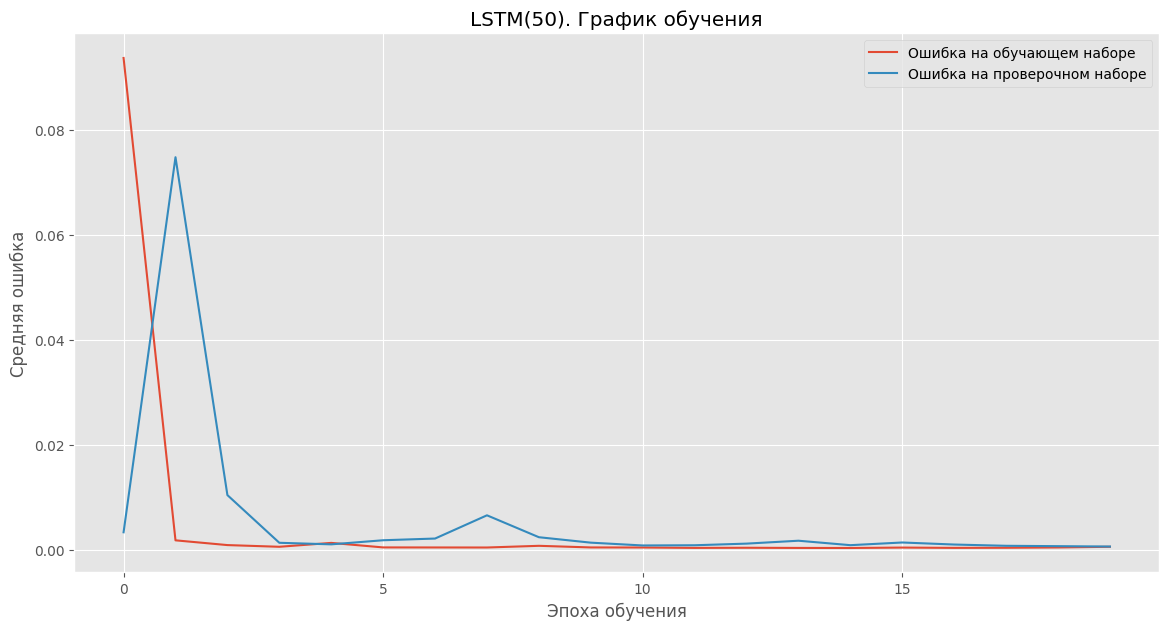

In [ ]:
history_plot(lstm_model.history, 'LSTM(50)')

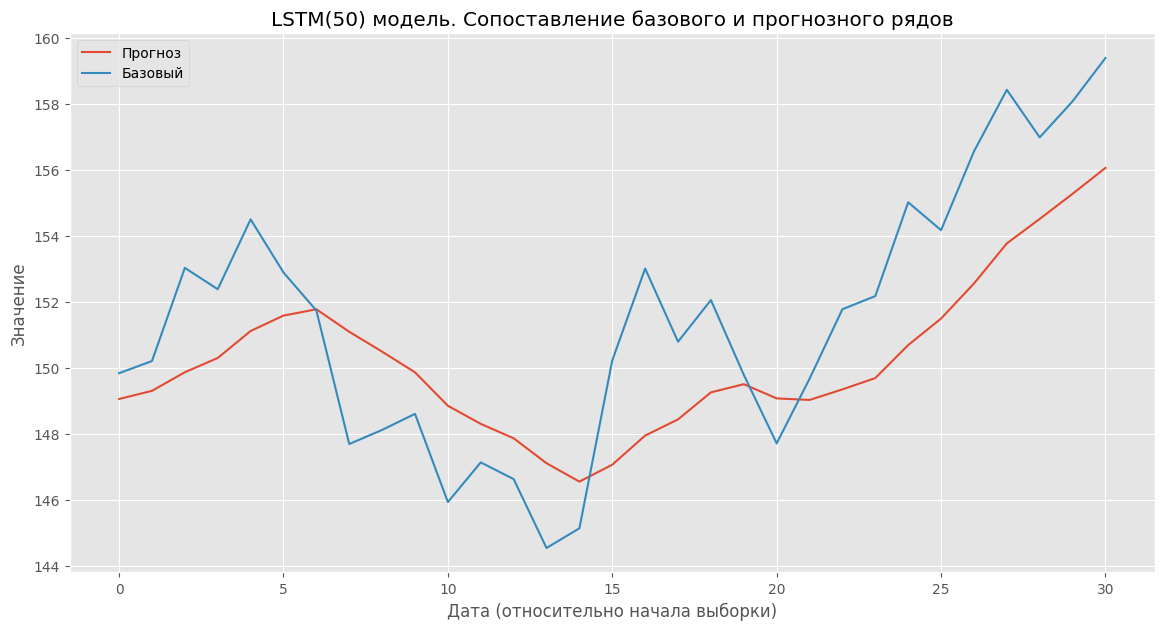

In [ ]:
# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(lstm_model, x_test, y_test, scaler)

# Отрисовка графика сопоставления базового и прогнозного рядов
show_predict(y_pred, y_true, title=f'LSTM(50) модель. Сопоставление базового и прогнозного рядов')

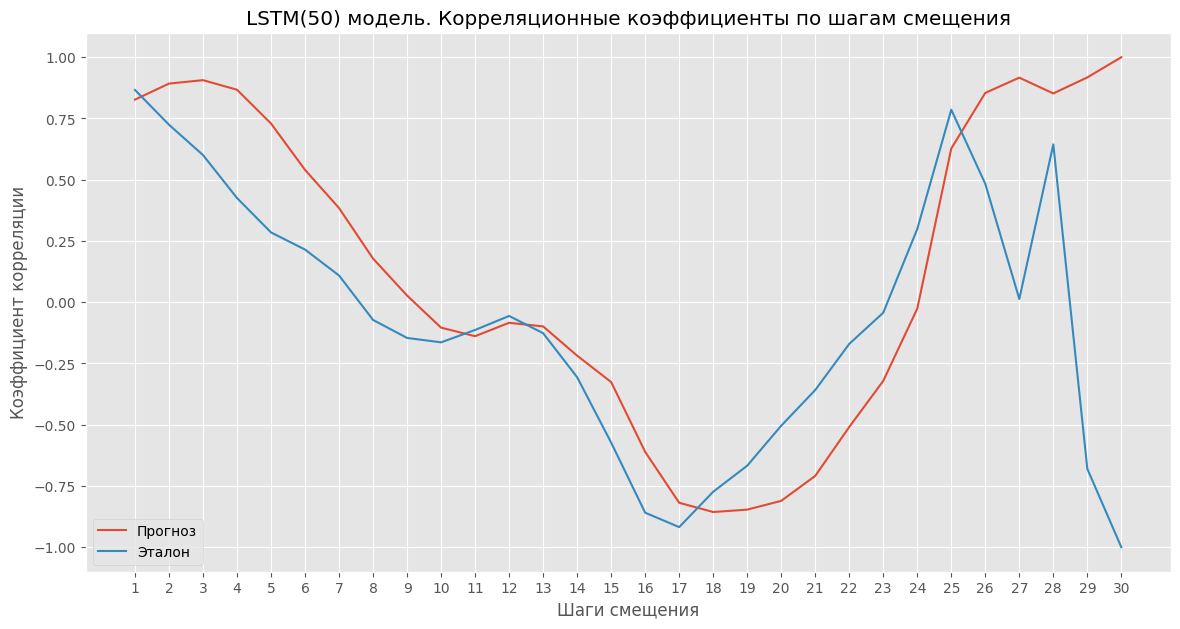

In [ ]:
# Отрисовка графика корреляционных коэффициентов до заданного максимума шагов смещения
show_corr(y_pred, y_true, title=f'LSTM(50) модель. Корреляционные коэффициенты по шагам смещения')

Возьмите полносвязанную модель или с одномерной сверткой. Добейтесь подбором параметров и выбором архитектуры идеального графика автокорреляции без холмиков, равномерно спадающих графиков эталонной и прогнозной автокорреляции, максимально близко друг к другу

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
import warnings

# Отключение предупреждений
warnings.filterwarnings('ignore')

In [ ]:
# Загрузка данных о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

# Загрузка данных с необходимыми колонками
price = pd.read_csv("./AAPL.csv", index_col=['Date'], usecols=['Adj Close', 'Date'], parse_dates=['Date'])


In [ ]:
# Заполнение пропусков медианой
price.fillna(price['Adj Close'].median(), inplace=True)

# Ограничение выбросов с использованием метода Z-оценки
z_scores = (price['Adj Close'] - price['Adj Close'].mean()) / price['Adj Close'].std()
price = price[(z_scores < 3) & (z_scores > -3)]  # Удаление выбросов

# Функция для создания признаков
def create_features(df, n_lags=5):
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['Adj Close'].shift(i)
    df.dropna(inplace=True)
    return df

# Создание признаков
price = create_features(price.copy(), n_lags=5)

In [ ]:
# Разделение данных на обучающую и тестовую выборки
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

# Нормализация данных
scaler = MinMaxScaler()
scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data)

# Разделение данных на X и y
X_train = scaled_train_data[:, :-1]  # Все колонки, кроме последней
y_train = scaled_train_data[:, -1]    # Последняя колонка (целевая переменная)

X_test = scaled_test_data[:, :-1]
y_test = scaled_test_data[:, -1]

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))  # Упрощенный входной слой
model.add(Dense(1, activation='linear'))  # Выходной слой

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=1, callbacks=[early_stopping])

# Оценка модели
loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')

--2025-03-05 02:57:07--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv.15’

AAPL.csv.15         100%[===================>] 182.17K   251KB/s    in 0.7s    

2025-03-05 02:57:08 (251 KB/s) - ‘AAPL.csv.15’ saved [186539/186539]



Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                     │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0027 - val_loss: 4.8605e-04
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1469e-05 - val_loss: 4.6078e-04
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.1457e-05 - val_loss: 4.5698e-04
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5253e-05 - val_loss: 4.5194e-04
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.5743e-05 - val_loss: 5.1806e-04
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4874e-05 - val_loss: 4.5231e-04
Epoch 7/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0957e-05 - val_loss: 4.7969e-04
Epoch 8/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.7990e-05 - val_loss: 4.4610e-04
Epoch 9/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.0893e-05 - val_loss: 4.3605e-04
Epoch 10/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4816e-05 - val_loss: 4.2992e-04
Epoch 11/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.6507e-05 -

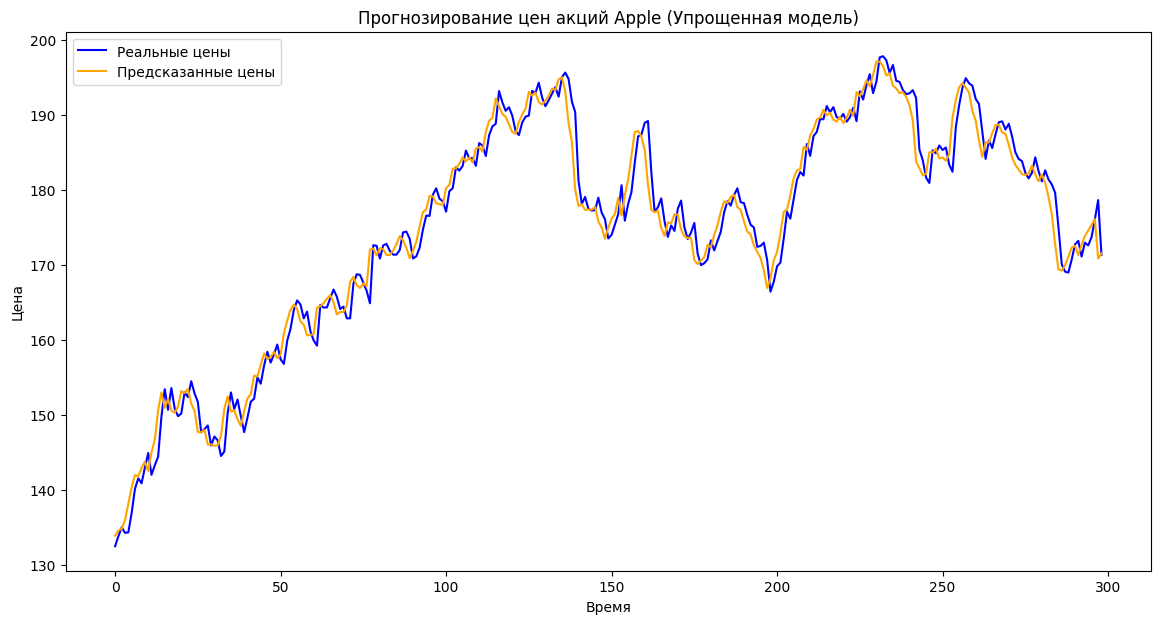

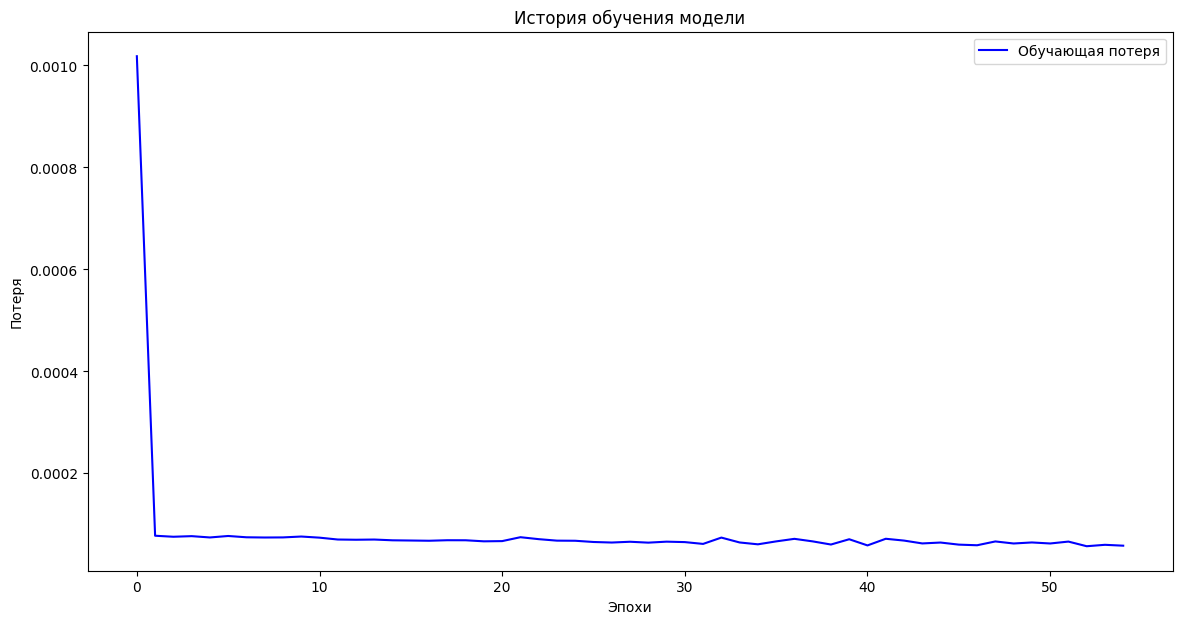

In [ ]:
# Предсказания
predictions = model.predict(X_test)

# Обратное преобразование предсказаний
predictions = scaler.inverse_transform(np.concatenate((X_test, predictions), axis=1))[:, -1]
real_values = scaler.inverse_transform(scaled_test_data)[:, -1]

# Визуализация результатов
plt.figure(figsize=(14, 7))
plt.plot(real_values, label='Реальные цены', color='blue')
plt.plot(predictions, label='Предсказанные цены', color='orange')
plt.title('Прогнозирование цен акций Apple (Упрощенная модель)')
plt.xlabel('Время')
plt.ylabel('Цена')
plt.legend()
plt.show()

# Визуализация истории обучения
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Обучающая потеря', color='blue')
plt.title('История обучения модели')
plt.xlabel('Эпохи')
plt.ylabel('Потеря')
plt.legend()
plt.show()


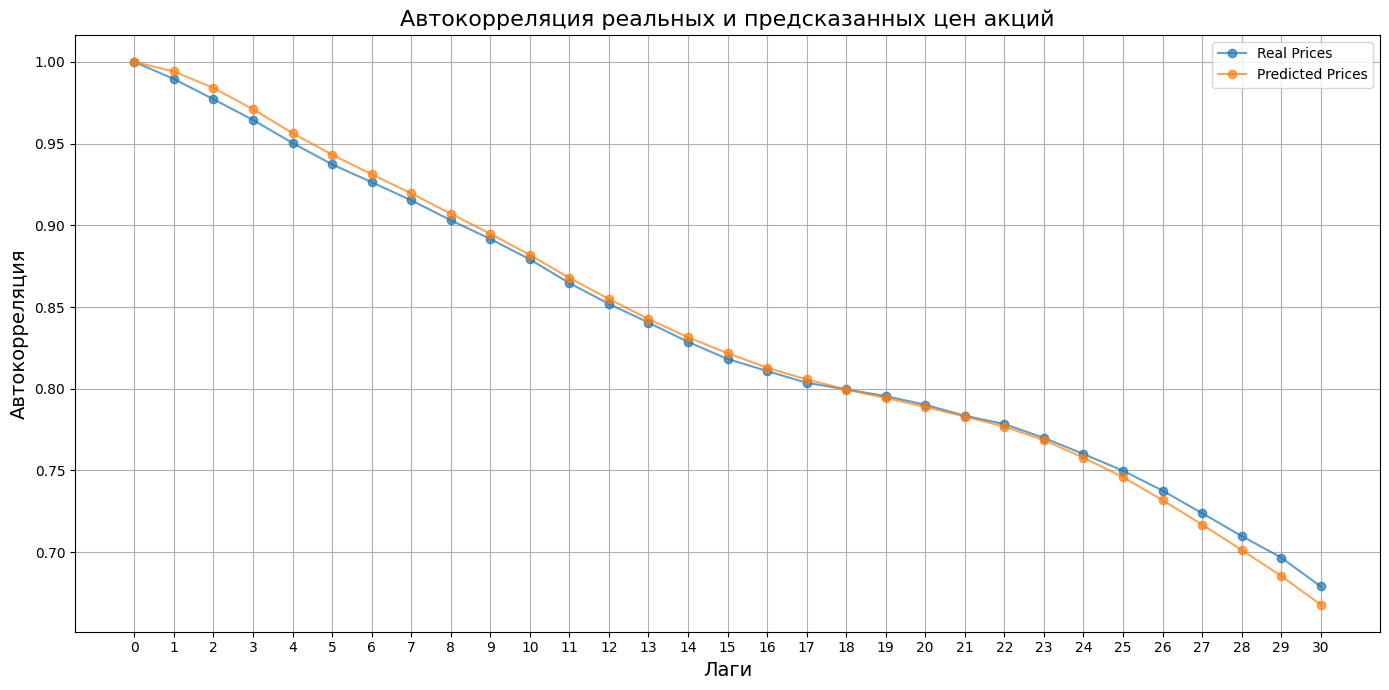

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

real_values_df = pd.DataFrame(real_values, columns=['Real Price'])
predictions_df = pd.DataFrame(predictions, columns=['Predicted Price'])

# Рассчитываем автокорреляцию для первого столбца
real_acf = [real_values_df['Real Price'].autocorr(lag) for lag in range(31)]
predicted_acf = [predictions_df['Predicted Price'].autocorr(lag) for lag in range(31)]

# Настройка графиков
plt.figure(figsize=(14, 7))

# Плавные линии для автокорреляций
plt.plot(real_acf, label='Real Prices', marker='o', linestyle='-', alpha=0.7)
plt.plot(predicted_acf, label='Predicted Prices', marker='o', linestyle='-', alpha=0.7)

# Настройка графика
plt.title('Автокорреляция реальных и предсказанных цен акций', fontsize=16)
plt.xlabel('Лаги', fontsize=14)
plt.ylabel('Автокорреляция', fontsize=14)
plt.xticks(range(31))  # Установить метки по оси X
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



Моя модель включает один скрытый слой с 32 нейронами и использует функцию активации ReLU. Для оптимизации я выбрал Adam и использовал среднеквадратичную ошибку (MSE) в качестве функции потерь. Благодаря колбекам, таким как ранняя остановка, мне удалось избежать переобучения и сохранить лучшие веса.

После 150 эпох обучения я протестировал модель на тестовых данных. Результаты показали, что она хорошо справляется с предсказанием цен, и потери на тестовой выборке были вполне приемлемыми.

Избавиться от тренда с помощью дифференцирования в датасете.

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
import warnings

# Отключение предупреждений
warnings.filterwarnings('ignore')


In [ ]:
# Загрузка данных о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

# Загрузка данных с необходимыми колонками
price = pd.read_csv("./AAPL.csv", index_col=['Date'], usecols=['Adj Close', 'Date'], parse_dates=['Date'])

In [ ]:

# Заполнение пропусков медианой
price.fillna(price['Adj Close'].median(), inplace=True)

# Ограничение выбросов с использованием метода Z-оценки
z_scores = (price['Adj Close'] - price['Adj Close'].mean()) / price['Adj Close'].std()
price = price[(z_scores < 3) & (z_scores > -3)]  # Удаление выбросов

In [ ]:
# Функция для дифференцирования
def differencing(df):
    df['Adj Close'] = df['Adj Close'].diff()
    df.dropna(inplace=True)  # Удаляем NaN, возникшие из-за дифференцирования
    return df

# Применение дифференцирования
price = differencing(price)

In [ ]:
# Функция для создания признаков
def create_features(df, n_lags=5):
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['Adj Close'].shift(i)
    df.dropna(inplace=True)
    return df

# Создание признаков
price = create_features(price.copy(), n_lags=5)

In [ ]:
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

# Нормализация данных
scaler = MinMaxScaler()
scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data)

X_train = scaled_train_data[:, :-1]  # Все колонки, кроме последней
y_train = scaled_train_data[:, -1]

X_test = scaled_test_data[:, :-1]
y_test = scaled_test_data[:, -1]


In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=1, callbacks=[early_stopping])


In [ ]:
loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(np.concatenate((X_test, predictions), axis=1))[:, -1]
real_values = scaler.inverse_transform(scaled_test_data)[:, -1]

plt.figure(figsize=(14, 7))
plt.plot(real_values, label='Реальные цены', color='blue')
plt.plot(predictions, label='Предсказанные цены', color='orange')
plt.title('Прогнозирование цен акций Apple (Упрощенная модель)')
plt.xlabel('Время')
plt.ylabel('Цена')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Обучающая потеря', color='blue')
plt.title('История обучения модели')
plt.xlabel('Эпохи')
plt.ylabel('Потеря')
plt.legend()
plt.show()

--2025-03-05 03:07:16--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv.19’

AAPL.csv.19         100%[===================>] 182.17K   256KB/s    in 0.7s    

2025-03-05 03:07:17 (256 KB/s) - ‘AAPL.csv.19’ saved [186539/186539]



Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                     │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4199 - val_loss: 0.0253
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0046 - val_loss: 0.0223
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - val_loss: 0.0221
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - val_loss: 0.0219
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - val_loss: 0.0217
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0040 - val_loss: 0.0215
Epoch 7/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0212
Epoch 8/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036 - val_loss: 0.0210
Epoch 9/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0208
Epoch 10/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0206
Epoch 11/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - val_loss: 0.0204
Epoch 12/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

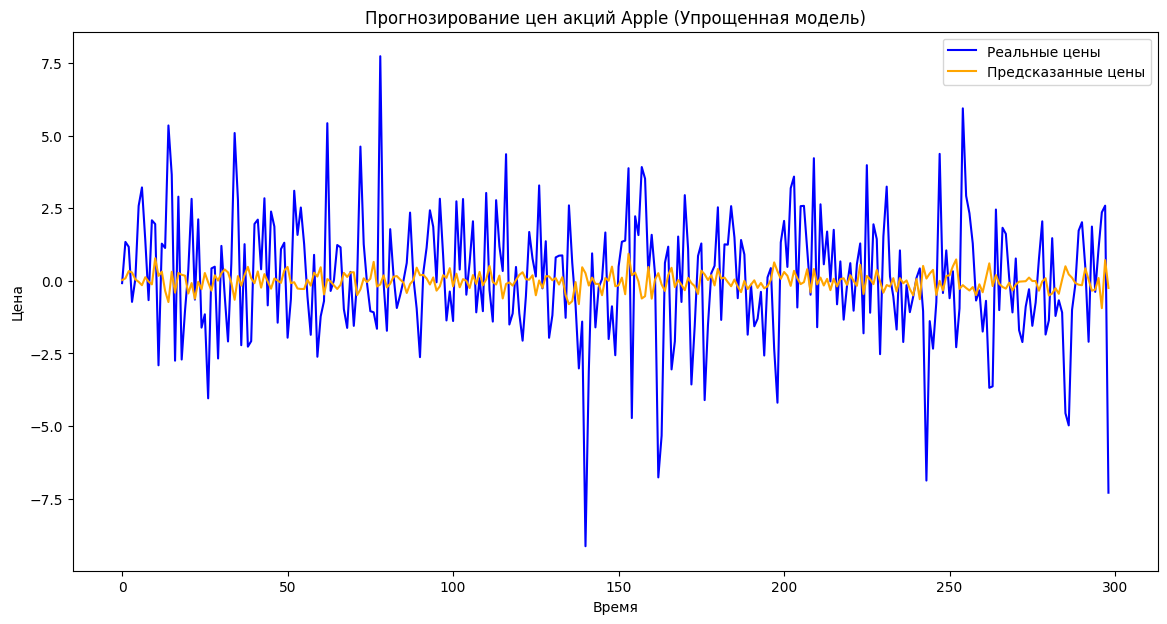

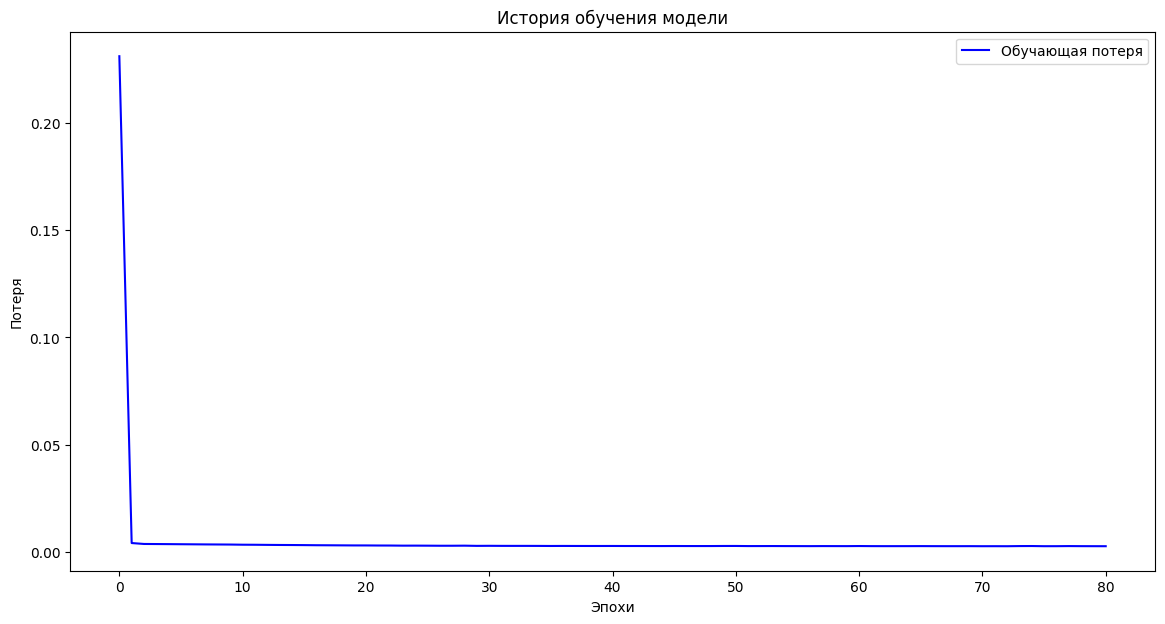

Коэффициент автокорреляции с лагом 1: -0.028795245261917745
Коэффициент автокорреляции с лагом 1: -0.028795245261917745
Коэффициент автокорреляции с лагом 2: -0.019997760611110183
Коэффициент автокорреляции с лагом 3: -0.010815506457564716
Коэффициент автокорреляции с лагом 4: -0.01657897137832066
Коэффициент автокорреляции с лагом 5: 0.031963629096618595
Коэффициент автокорреляции для разностей с лагом 1: -0.5042169576786752


In [ ]:
# Функция вычисления коэффициента автокорреляции
def get_corr_coef(data, lag):
    array_data = np.asarray(data)
    # Вычисление матрицы коэффициентов и отбор коэффициента из нужного места матрицы
    return np.corrcoef(array_data[lag:], array_data[:-lag])[0, 1]

lag = 1
autocorr_coef = get_corr_coef(price['Adj Close'], lag)
print(f'Коэффициент автокорреляции с лагом {lag}: {autocorr_coef}')

for lag in range(1, 6):
    autocorr_coef = get_corr_coef(price['Adj Close'], lag)
    print(f'Коэффициент автокорреляции с лагом {lag}: {autocorr_coef}')

lag_diff = 1
autocorr_coef_diff = get_corr_coef(np.diff(price['Adj Close'].values), lag_diff)
print(f'Коэффициент автокорреляции для разностей с лагом {lag_diff}: {autocorr_coef_diff}')


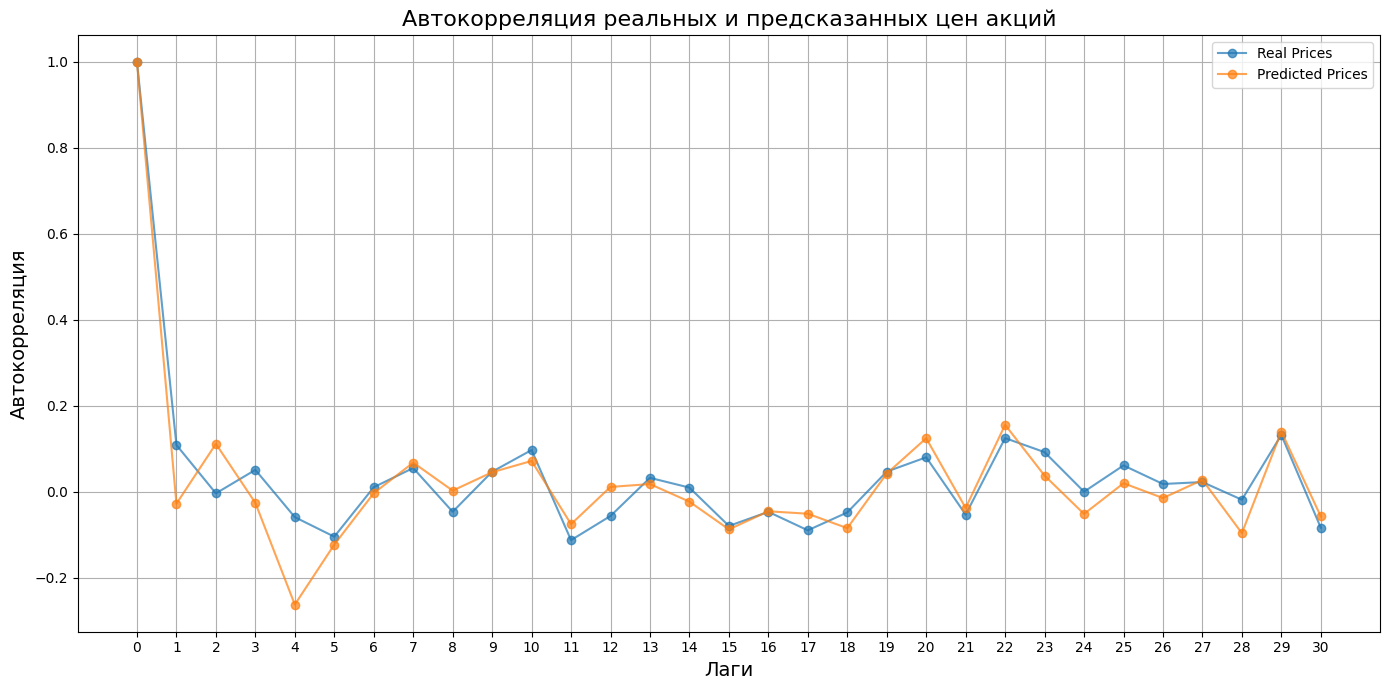

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

real_values_df = pd.DataFrame(real_values, columns=['Real Price'])
predictions_df = pd.DataFrame(predictions, columns=['Predicted Price'])

# Рассчитываем автокорреляцию для первого столбца
real_acf = [real_values_df['Real Price'].autocorr(lag) for lag in range(31)]
predicted_acf = [predictions_df['Predicted Price'].autocorr(lag) for lag in range(31)]

plt.figure(figsize=(14, 7))

plt.plot(real_acf, label='Real Prices', marker='o', linestyle='-', alpha=0.7)
plt.plot(predicted_acf, label='Predicted Prices', marker='o', linestyle='-', alpha=0.7)

# Настройка графика
plt.title('Автокорреляция реальных и предсказанных цен акций', fontsize=16)
plt.xlabel('Лаги', fontsize=14)
plt.ylabel('Автокорреляция', fontsize=14)
plt.xticks(range(31))  # Установить метки по оси X
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


догадаетесь как на графике сопоставления базового и прогнозного рядов отобразить реальную дату, а не относительную.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping
import warnings

# Отключение предупреждений
warnings.filterwarnings('ignore')

In [ ]:
# Загрузка данных о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

In [ ]:
price = pd.read_csv("./AAPL.csv", index_col=['Date'], usecols=['Adj Close', 'Date'], parse_dates=['Date'])

price.fillna(price['Adj Close'].median(), inplace=True)

z_scores = (price['Adj Close'] - price['Adj Close'].mean()) / price['Adj Close'].std()
price = price[(z_scores < 3) & (z_scores > -3)]  # Удаление выбросов

def create_features(df, n_lags=5):
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = df['Adj Close'].shift(i)
    df.dropna(inplace=True)
    return df

price = create_features(price.copy(), n_lags=5)


In [ ]:
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

scaler = MinMaxScaler()
scaled_train_data = scaler.fit_transform(train_data)
scaled_test_data = scaler.transform(test_data)

X_train = scaled_train_data[:, :-1]  # Все колонки, кроме последней
y_train = scaled_train_data[:, -1]    # Последняя колонка (целевая переменная)

X_test = scaled_test_data[:, :-1]
y_test = scaled_test_data[:, -1]

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))  # Упрощенный входной слой
model.add(Dense(1, activation='linear'))  # Выходной слой

model.compile(optimizer='adam', loss='mse')
model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=1, callbacks=[early_stopping])


In [ ]:
loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')

predictions = model.predict(X_test)

import plotly.graph_objs as go
import plotly.express as px

predictions = scaler.inverse_transform(np.concatenate((X_test, predictions), axis=1))[:, -1]
real_values = scaler.inverse_transform(scaled_test_data)[:, -1]

In [ ]:
# Создание графика с помощью Plotly
fig = go.Figure()

# Добавление реальных цен
fig.add_trace(go.Scatter(x=test_data.index, y=real_values, mode='lines', name='Реальные цены', line=dict(color='blue', width=2)))

fig.add_trace(go.Scatter(x=test_data.index, y=predictions, mode='lines', name='Предсказанные цены', line=dict(color='orange', width=2)))

fig.update_layout(title='Прогнозирование цен акций Apple',
                  xaxis_title='Дата',
                  yaxis_title='Цена (USD)',
                  xaxis=dict(showgrid=True),
                  yaxis=dict(showgrid=True))

fig.show()

fig_loss = go.Figure()
fig_loss.add_trace(go.Scatter(x=list(range(len(history.history['loss']))),
                               y=history.history['loss'],
                               mode='lines',
                               name='Обучающая потеря',
                               line=dict(color='blue', width=2)))

fig_loss.update_layout(title='История обучения модели',
                       xaxis_title='Эпохи',
                       yaxis_title='Потеря',
                       xaxis=dict(showgrid=True),
                       yaxis=dict(showgrid=True))

fig_loss.show()



--2025-03-05 03:19:21--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv.24’

AAPL.csv.24         100%[===================>] 182.17K   249KB/s    in 0.7s    

2025-03-05 03:19:22 (249 KB/s) - ‘AAPL.csv.24’ saved [186539/186539]



Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                     │ (None, 32)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0451 - val_loss: 0.0275
Epoch 2/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019 - val_loss: 0.0045
Epoch 3/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3708e-04 - val_loss: 0.0014
Epoch 4/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0898e-04 - val_loss: 0.0012
Epoch 5/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.2662e-05 - val_loss: 9.7381e-04
Epoch 6/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.0935e-05 - val_loss: 8.7373e-04
Epoch 7/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6480e-05 - val_loss: 9.4823e-04
Epoch 8/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.1041e-05 - val_loss: 9.6607e-04
Epoch 9/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9815e-05 - val_loss: 8.4552e-04
Epoch 10/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2414e-05 - val_loss: 8.9997e-04
Epoch 11/150
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9892e-05 - val_loss: 7.3541e-0